# Space Debris Detection & Trajectory Prediction — Complete Implementation

### **Task 1:** Debris Detection — Random Forest + Gradient Boosting with 


## Importing Libraries 

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
from sgp4.api import Satrec
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.style.use('ggplot')

In [2]:
import sys
print(sys.executable)

C:\Users\shukl\myenv\Scripts\python.exe


In [3]:
import os
EARTH_RADIUS = 6371.0     
MU           = 398600.4418  

print('Constants initialised.')


Constants initialised.


# TASK-1 Active Satellite and Debris Detecion with Full Feature Set 

### SGP4 Parsing Logic 

In [12]:
def read_tle_file(filepath):
    with open(filepath, 'r') as f:
        lines = f.readlines()
    return [line.strip() for line in lines if line.strip()]

def parse_tle_basic(lines, label):
    records = []
    for i in range(0, len(lines) - 2, 3):
        try:
            line1 = lines[i + 1].strip()
            line2 = lines[i + 2].strip()
            if not line1.startswith('1') or not line2.startswith('2'):
                continue

            norad_id = line1[2:7].strip()
            sat = Satrec.twoline2rv(line1, line2)

            records.append({
                'norad_id'     : norad_id,
                'eccentricity' : sat.ecco,
                'inclination'  : np.degrees(sat.inclo),
                'raan'         : np.degrees(sat.nodeo),
                'arg_perigee'  : np.degrees(sat.argpo),
                'mean_anomaly' : np.degrees(sat.mo),
                'mean_motion'  : sat.no_kozai * (1440 / (2 * np.pi)),
                'label'        : label,
            })
        except Exception:
            continue
    return records

###  Load static TLE files 

In [26]:
print('Loading and Parsing Files...')
# Training files (Older data)
train_active = read_tle_file('active-sate.txt')
train_deb1   = read_tle_file('cosmos-1408-debris.txt')
train_deb2   = read_tle_file('cosmos-2251-debris.txt')
train_deb3   = read_tle_file('iridium-33-debris.txt')
train_deb4   = read_tle_file('fengyun-1c-debris.txt')

# New testing files
test_active  = read_tle_file('26_Data set/ACTIVE SATELLITE.txt')
test_deb1    = read_tle_file('26_Data set/COSMOS 2251 DEB.txt')
test_deb2    = read_tle_file('26_Data set/IRIDIUM 33 DEB.txt')

all_records = parse_tle_basic(train_active, 0) + \
              parse_tle_basic(train_deb1, 1) + \
              parse_tle_basic(train_deb2, 1) + \
              parse_tle_basic(train_deb3, 1) + \
              parse_tle_basic(train_deb4, 1) + \
              parse_tle_basic(test_active, 0) + \
              parse_tle_basic(test_deb1, 1) + \
              parse_tle_basic(test_deb2, 1)

df_all = pd.DataFrame(all_records)
FEAT_COLS = ['eccentricity', 'inclination', 'raan', 'arg_perigee', 'mean_anomaly', 'mean_motion']
print(f'Total records: {len(df_all):,}')
print(f'Unique objects: {df_all.norad_id.nunique():,}')


Loading and Parsing Files...
Total records: 33,754
Unique objects: 17,959


### Dataset Building 

In [28]:
print("Extracting features from TLE files...")
train_files = {'active-sate.txt': 0, 'cosmos-1408-debris.txt': 1, 'cosmos-2251-debris.txt': 1, 
               'iridium-33-debris.txt': 1, 'fengyun-1c-debris.txt': 1}
test_files = {'26_Data set/ACTIVE SATELLITE.txt': 0, '26_Data set/COSMOS 2251 DEB.txt': 1, '26_Data set/IRIDIUM 33 DEB.txt': 1}

all_records = []
for f, lbl in {**train_files, **test_files}.items():
    all_records += parse_tle_basic(read_tle_file(f), lbl)

df = pd.DataFrame(all_records)
FEAT_COLS = ['eccentricity', 'inclination', 'raan', 'arg_perigee', 'mean_anomaly', 'mean_motion']

Extracting features from TLE files...


### Feature Distribution Plots 

Generating Feature Distributions...


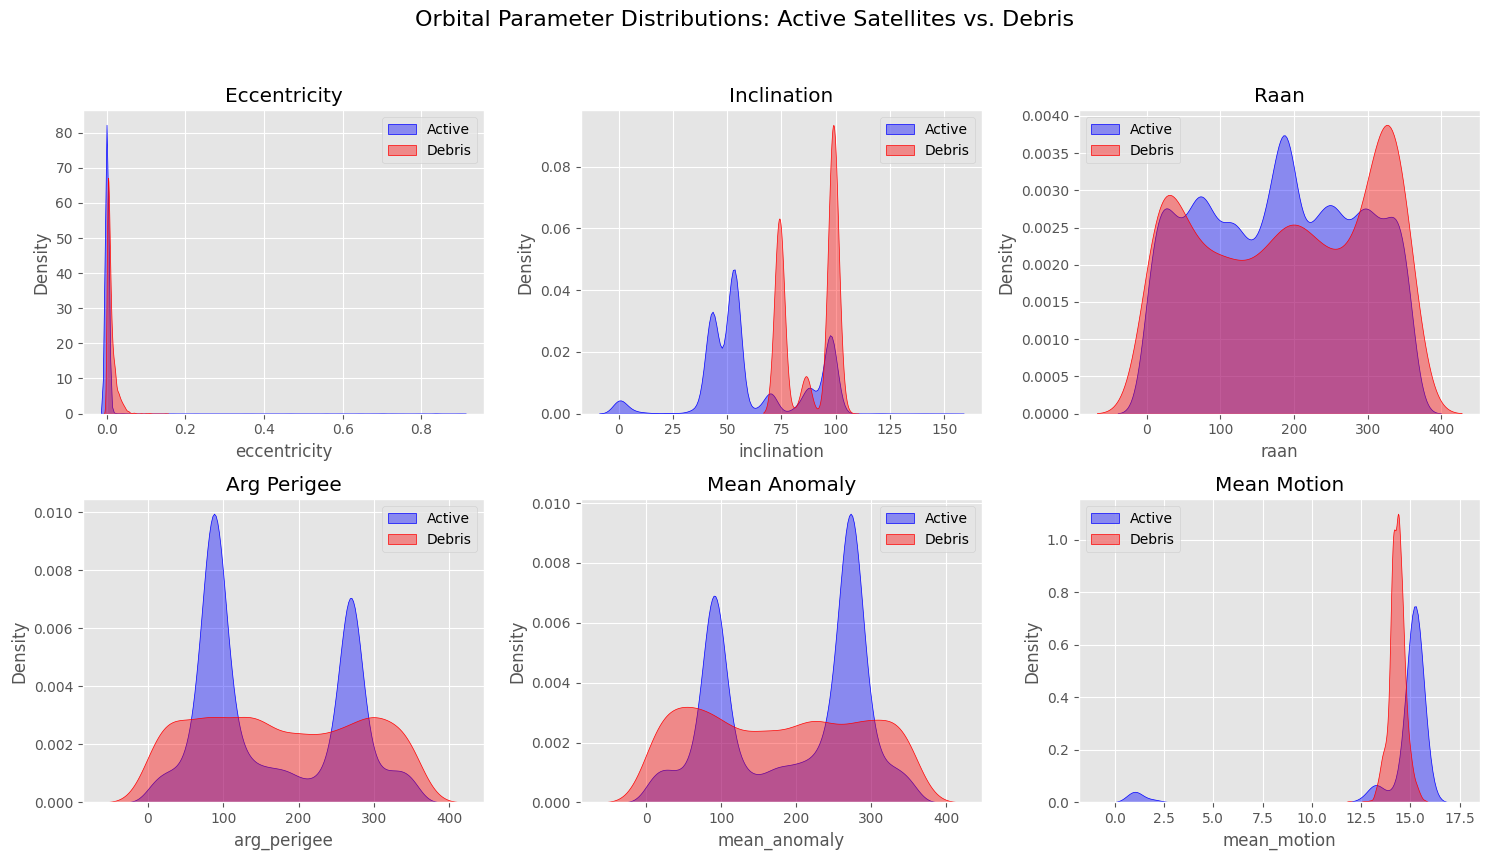

In [29]:
print("Generating Feature Distributions...")
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Orbital Parameter Distributions: Active Satellites vs. Debris', fontsize=16)

for i, col in enumerate(FEAT_COLS):
    ax = axes[i//3, i%3]
    sns.kdeplot(data=df[df.label==0], x=col, label='Active', ax=ax, fill=True, color='blue', alpha=0.4)
    sns.kdeplot(data=df[df.label==1], x=col, label='Debris', ax=ax, fill=True, color='red', alpha=0.4)
    ax.set_title(col.replace('_', ' ').title())
    ax.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Object based Train/Test Split

In [36]:
print("\nPerforming Group Splitting by NORAD ID...")
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=df['norad_id']))

df_train_raw = df.iloc[train_idx]
df_test = df.iloc[test_idx]

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(df_train_raw[FEAT_COLS], df_train_raw['label'])
X_test, y_test = df_test[FEAT_COLS], df_test['label']

print("Training Models (Random Forest & Gradient Boosting)...")
rf = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train_bal, y_train_bal)
gb = GradientBoostingClassifier(n_estimators=100, random_state=42).fit(X_train_bal, y_train_bal)

rf_acc = accuracy_score(y_test, rf.predict(X_test)) * 100
gb_acc = accuracy_score(y_test, gb.predict(X_test)) * 100


Performing Group Splitting by NORAD ID...
Training Models (Random Forest & Gradient Boosting)...


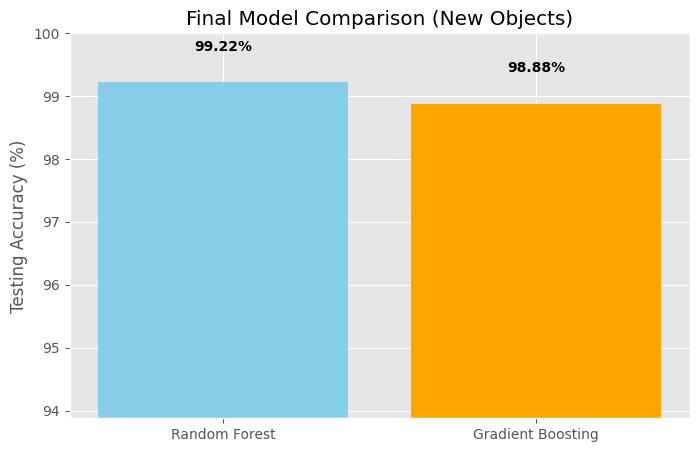

In [41]:
plt.figure(figsize=(8, 5))
plt.bar(['Random Forest', 'Gradient Boosting'], [rf_acc, gb_acc], color=['skyblue', 'orange'])
plt.ylabel('Testing Accuracy (%)')
plt.title('Final Model Comparison (New Objects)')
plt.ylim(min(rf_acc, gb_acc)-5, 100)
for i, v in enumerate([rf_acc, gb_acc]):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha='center', fontweight='bold')
plt.show()

### Feature Importance 

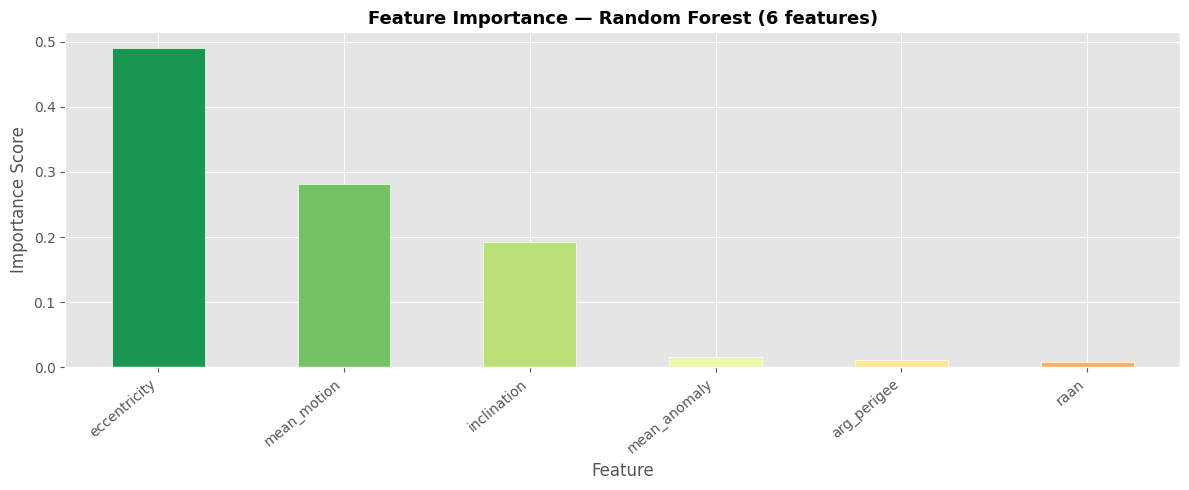

Top 5 most important features:
  eccentricity                   0.4899
  mean_motion                    0.2821
  inclination                    0.1933
  mean_anomaly                   0.0161
  arg_perigee                    0.0111


In [37]:
fi = pd.Series(rf.feature_importances_, index=FEAT_COLS)
fi = fi.sort_values(ascending=False)

plt.figure(figsize=(12, 5))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(fi))[::-1])
fi.plot(kind='bar', color=colors, edgecolor='white')
plt.title('Feature Importance — Random Forest (6 features)',
          fontsize=13, fontweight='bold')
plt.ylabel('Importance Score')
plt.xlabel('Feature')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

print('Top 5 most important features:')
for feat, score in fi.head(5).items():
    print(f'  {feat:<30} {score:.4f}')

### Final Evaluation

In [39]:
print("\n" + "="*40)
print("   FINAL CLASSIFICATION REPORT (UNSEEN OBJECTS)")
print("="*40)
print("\nRANDOM FOREST MODEL:")
print(classification_report(y_test, rf.predict(X_test), target_names=['Active', 'Debris']))

print("\nGRADIENT BOOSTING MODEL:")
print(classification_report(y_test, gb.predict(X_test), target_names=['Active', 'Debris']))


   FINAL CLASSIFICATION REPORT (UNSEEN OBJECTS)

RANDOM FOREST MODEL:
              precision    recall  f1-score   support

      Active       1.00      0.99      1.00      6086
      Debris       0.93      0.99      0.96       688

    accuracy                           0.99      6774
   macro avg       0.97      0.99      0.98      6774
weighted avg       0.99      0.99      0.99      6774


GRADIENT BOOSTING MODEL:
              precision    recall  f1-score   support

      Active       1.00      0.99      0.99      6086
      Debris       0.91      0.99      0.95       688

    accuracy                           0.99      6774
   macro avg       0.95      0.99      0.97      6774
weighted avg       0.99      0.99      0.99      6774

